4. Recurrent neural network (RNN) Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load dataset
data = pd.read_csv("D:\TE-Computer\sem VII\DL\Google_Stock_Price_Test.csv")
prices = data['Open'].values.reshape(-1,1)

In [3]:

# Use 'Open' price
data['Open'] = pd.to_numeric(data['Open'], errors='coerce')
data = data.dropna()

prices = data['Open'].values.reshape(-1,1)

# Normalize
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)


In [4]:
# Create sequences (past 60 days)
X, y = [], []
for i in range(60, len(prices)):
    X.append(prices[i-60:i])
    y.append(prices[i])

X, y = np.array(X), np.array(y)


In [5]:
# Build RNN
model = Sequential([
    SimpleRNN(50, input_shape=(60,1)),
    Dense(1)
])
model.summary()


c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile
model.compile(optimizer='adam', loss='mse')


In [10]:
# Train
# Train
model.compile(optimizer='adam', loss='mse')
history = model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.6467
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.5033
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.3806
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2779
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1950


In [11]:

# Predict
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


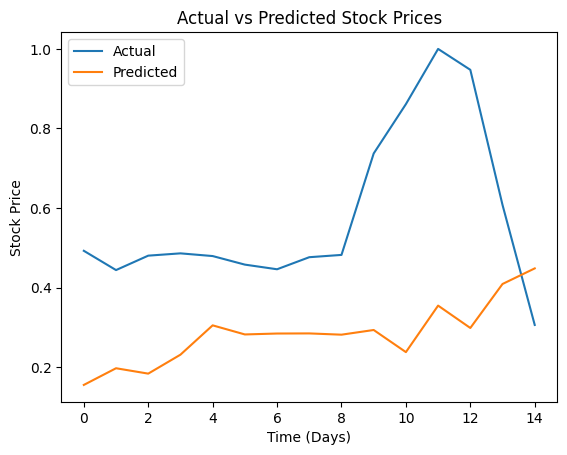

In [12]:
plt.plot(y, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time (Days)")
plt.ylabel("Stock Price")
plt.show()